In [2]:
import pandas as pd

df = pd.read_csv(r'Joins datasets/dataset_temporal_final.csv')

df.isna().sum()

Unnamed: 0               0
date                     0
home_team                0
away_team                0
home_score               0
away_score               0
tournament               0
city                     0
country                  0
neutral                  0
winner                   0
first_shooter            0
home_form_pts            0
away_form_pts            0
home_venue_type          0
home_aproveitamento      0
away_venue_type          0
away_aproveitamento      0
rest_days_diff           0
home_h2h_pts             0
away_h2h_pts             0
home_form_gd             0
away_form_gd             0
home_pen_win_rate        0
away_pen_win_rate        0
tournament_weight        0
home_Rank              123
home_TotalPoints         0
away_Rank              135
away_TotalPoints         0
home_GER                 0
home_ATQ                 0
home_MED                 0
home_DEF                 0
away_GER                 0
away_ATQ                 0
away_MED                 0
a

In [3]:
df.dropna(inplace=True)

In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df = pd.get_dummies(df, columns=['home_venue_type', 'away_venue_type'])
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'winner', 'first_shooter',
       'home_form_pts', 'away_form_pts', 'home_aproveitamento',
       'away_aproveitamento', 'rest_days_diff', 'home_h2h_pts', 'away_h2h_pts',
       'home_form_gd', 'away_form_gd', 'home_pen_win_rate',
       'away_pen_win_rate', 'tournament_weight', 'home_Rank',
       'home_TotalPoints', 'away_Rank', 'away_TotalPoints', 'home_GER',
       'home_ATQ', 'home_MED', 'home_DEF', 'away_GER', 'away_ATQ', 'away_MED',
       'away_DEF', 'home_venue_type_Casa', 'home_venue_type_Neutro',
       'away_venue_type_Fora', 'away_venue_type_Neutro'],
      dtype='str')

In [5]:
group_fixtures = pd.read_csv(r'group_fixtures.csv')
knockout_slots = pd.read_csv(r'knockout_slots.csv')
# Converter data para datetime
group_fixtures['date'] = pd.to_datetime(group_fixtures['date_utc'])

In [26]:
# ============================================================
# SEÇÃO 6: VALIDAÇÃO DE PRECISÃO (BACKTESTING COPA 2022)
# ============================================================
print("=" * 62)
print("🎯 AVALIAÇÃO DE PRECISÃO DO MODELO (FASE DE GRUPOS 2022)")
print("=" * 62)

# 1. Isolar os resultados reais da Copa do Mundo de 2022
# A fase de grupos ocorreu aproximadamente entre 20/11/2022 e 02/12/2022
df_real_wc = df[(df['date'] >= '2022-11-20') &
                (df['date'] <= '2022-12-02') &
                (df['tournament'] == 'FIFA World Cup')]

acertos_resultado = 0 # Vitória Mandante, Vitória Visitante ou Empate
acertos_placar = 0    # Placar Exato (ex: 2-1 cravado)
total_jogos = 0
jogos_avaliados = []

for jogo in jogos_grupo_2022:
    t1 = jogo['home_team']
    t2 = jogo['away_team']

    # 2. Resgatar a previsão feita pelo Monte Carlo
    cnt = acc_placar_grupo.get((t1, t2), Counter())
    if not cnt:
        continue

    # <-- VOLTAMOS AQUI PARA A MODA (O Placar mais frequente) -->
    (h_pred, a_pred), _ = cnt.most_common(1)[0]

    if h_pred > a_pred: res_pred = 'Vencedor 1'
    elif h_pred < a_pred: res_pred = 'Vencedor 2'
    else: res_pred = 'Empate'

    # 3. Procurar o jogo na base real (lidando com inversão de mandante/visitante)
    jogo_real = df_real_wc[((df_real_wc['home_team'] == t1) & (df_real_wc['away_team'] == t2)) |
                           ((df_real_wc['home_team'] == t2) & (df_real_wc['away_team'] == t1))]

    if not jogo_real.empty:
        total_jogos += 1
        row_real = jogo_real.iloc[0]

        # Normalizar o placar real para a perspectiva do T1
        if row_real['home_team'] == t1:
            h_real, a_real = row_real['home_score'], row_real['away_score']
        else:
            h_real, a_real = row_real['away_score'], row_real['home_score']

        if h_real > a_real: res_real = 'Vencedor 1'
        elif h_real < a_real: res_real = 'Vencedor 2'
        else: res_real = 'Empate'

        # 4. Computar Acertos
        acertou_res = (res_pred == res_real)
        acertou_pla = (h_pred == h_real and a_pred == a_real)

        if acertou_res: acertos_resultado += 1
        if acertou_pla: acertos_placar += 1

        jogos_avaliados.append({
            'Confronto': f"{t1} x {t2}",
            'Previsto': f"{int(h_pred)} - {int(a_pred)}",
            'Real': f"{int(h_real)} - {int(a_real)}",
            'Acertou Resultado?': '✅' if acertou_res else '❌',
            'Acertou Placar?': '🎯' if acertou_pla else '❌'
        })

# 5. Exibir o Relatório
print(f"Total de jogos avaliados: {total_jogos} (Deveriam ser 48 na fase de grupos)")
print(f"Precisão de Resultado (1x2): {(acertos_resultado / total_jogos) * 100:.1f}% ({acertos_resultado}/{total_jogos})")
print(f"Precisão de Placar Exato:    {(acertos_placar / total_jogos) * 100:.1f}% ({acertos_placar}/{total_jogos})")

print("\n┌─ DETALHAMENTO DOS JOGOS ──────────────────────────────────────────┐")
df_relatorio = pd.DataFrame(jogos_avaliados)
display(df_relatorio)
print("└───────────────────────────────────────────────────────────────────┘")

🎯 AVALIAÇÃO DE PRECISÃO DO MODELO (FASE DE GRUPOS 2022)
Total de jogos avaliados: 48 (Deveriam ser 48 na fase de grupos)
Precisão de Resultado (1x2): 52.1% (25/48)
Precisão de Placar Exato:    14.6% (7/48)

┌─ DETALHAMENTO DOS JOGOS ──────────────────────────────────────────┐


,Confronto,Previsto,Real,Acertou Resultado?,Acertou Placar?
0,Qatar x Ecuador,0 - 1,0 - 2,✅,❌
1,Qatar x Senegal,0 - 1,1 - 3,✅,❌
2,Qatar x Netherlands,0 - 1,0 - 2,✅,❌
3,Ecuador x Senegal,0 - 0,1 - 2,❌,❌
4,Ecuador x Netherlands,0 - 1,1 - 1,❌,❌
5,Senegal x Netherlands,0 - 1,0 - 2,✅,❌
6,England x IR Iran,1 - 0,6 - 2,✅,❌
7,England x USA,1 - 1,0 - 0,✅,❌
8,England x Wales,1 - 0,3 - 0,✅,❌
9,IR Iran x USA,0 - 1,0 - 1,✅,🎯


└───────────────────────────────────────────────────────────────────┘


In [18]:
# ============================================================
# SEÇÃO 9: MATA-MATA DETERMINÍSTICO (BACKTESTING COPA 2022)
# ============================================================
print("=" * 62)
print("⚔️ SIMULAÇÃO DO MATA-MATA (Caminho da Moda dos Grupos - 2022)")
print("=" * 62)

# 1. Garantir a reconstrução dos classificados por segurança
modo_primeiros = {}
modo_segundos = {}
for grupo in sorted(grupos_2022.keys()):
    times_g = grupos_2022[grupo]
    classif_mc = sorted(times_g, key=lambda t: _pos_media(grupo, t))
    modo_primeiros[grupo] = classif_mc[0]
    modo_segundos[grupo]  = classif_mc[1]

# 2. Função Determinística (Calcula o placar matemático mais provável via Moda)
def simular_partida_deterministica(home_team, away_team):
    lam = get_lambda_lgbm(home_team, away_team, is_home=0) # is_home=0 campo neutro na Copa
    mu  = get_lambda_lgbm(away_team, home_team, is_home=0)

    goals = np.arange(MAX_GOLS + 1)
    matrix = np.outer(poisson.pmf(goals, lam), poisson.pmf(goals, mu))
    idx = np.argmax(matrix)
    h, a = divmod(idx, MAX_GOLS + 1)
    return h, a

# 3. Estruturas de Rastreamento do Chaveamento
w_bracket = {}
l_bracket = {}
previsoes_ko = []

# Lógica de resolução do Slot adaptada para 2022 (Sem melhores 3ºs)
def resolver(slot_desc):
    s = str(slot_desc).strip()
    if s.startswith('Winner Group'):    return modo_primeiros.get(s[-1], 'TBD')
    if s.startswith('Runner-up Group'): return modo_segundos.get(s[-1], 'TBD')
    if s.startswith('Winner Match'):    return w_bracket.get(int(s.split()[-1]), 'TBD')
    if s.startswith('Loser Match'):     return l_bracket.get(int(s.split()[-1]), 'TBD')
    return 'TBD'

# 4. Definição Estrutural do Chaveamento Oficial da Copa de 2022 (Jogos 49 ao 64)
slots_2022 = [
    # --- OITAVAS DE FINAL ---
    {'match_id': 49, 'round': 'Round of 16', 'slot_home': 'Winner Group A', 'slot_away': 'Runner-up Group B'},
    {'match_id': 50, 'round': 'Round of 16', 'slot_home': 'Winner Group C', 'slot_away': 'Runner-up Group D'},
    {'match_id': 51, 'round': 'Round of 16', 'slot_home': 'Winner Group B', 'slot_away': 'Runner-up Group A'},
    {'match_id': 52, 'round': 'Round of 16', 'slot_home': 'Winner Group D', 'slot_away': 'Runner-up Group C'},
    {'match_id': 53, 'round': 'Round of 16', 'slot_home': 'Winner Group E', 'slot_away': 'Runner-up Group F'},
    {'match_id': 54, 'round': 'Round of 16', 'slot_home': 'Winner Group G', 'slot_away': 'Runner-up Group H'},
    {'match_id': 55, 'round': 'Round of 16', 'slot_home': 'Winner Group F', 'slot_away': 'Runner-up Group E'},
    {'match_id': 56, 'round': 'Round of 16', 'slot_home': 'Winner Group H', 'slot_away': 'Runner-up Group G'},
    # --- QUARTAS DE FINAL ---
    {'match_id': 57, 'round': 'Quarter-finals', 'slot_home': 'Winner Match 49', 'slot_away': 'Winner Match 50'},
    {'match_id': 58, 'round': 'Quarter-finals', 'slot_home': 'Winner Match 53', 'slot_away': 'Winner Match 54'},
    {'match_id': 59, 'round': 'Quarter-finals', 'slot_home': 'Winner Match 51', 'slot_away': 'Winner Match 52'},
    {'match_id': 60, 'round': 'Quarter-finals', 'slot_home': 'Winner Match 55', 'slot_away': 'Winner Match 56'},
    # --- SEMIFINAIS ---
    {'match_id': 61, 'round': 'Semi-finals', 'slot_home': 'Winner Match 57', 'slot_away': 'Winner Match 58'},
    {'match_id': 62, 'round': 'Semi-finals', 'slot_home': 'Winner Match 59', 'slot_away': 'Winner Match 60'},
    # --- TERCEIRO LUGAR E FINAL ---
    {'match_id': 63, 'round': 'Third-place playoff', 'slot_home': 'Loser Match 61', 'slot_away': 'Loser Match 62'},
    {'match_id': 64, 'round': 'Final', 'slot_home': 'Winner Match 61', 'slot_away': 'Winner Match 62'}
]
knockout_slots_2022 = pd.DataFrame(slots_2022)

fase_atual = ""

# 5. Executando a progressão do Chaveamento
for _, row in knockout_slots_2022.iterrows():
    m_id = row['match_id']
    fase = row['round']
    ht = resolver(row['slot_home'])
    at = resolver(row['slot_away'])

    if fase != fase_atual:
        print(f"\n{'═' * 62}\n  {fase.upper()}\n{'═' * 62}")
        fase_atual = fase

    if ht != 'TBD' and at != 'TBD':
        h, a = simular_partida_deterministica(ht, at)

        # Lógica de Pênaltis em caso de empate na Moda
        penalties = False
        if h > a:
            vencedor, perdedor = ht, at
            win_team_str = 'home'
        elif a > h:
            vencedor, perdedor = at, ht
            win_team_str = 'away'
        else:
            penalties = True
            ger_h = latest_stats.get(ht, default_stats)['GER']
            ger_a = latest_stats.get(at, default_stats)['GER']
            if ger_h >= ger_a:
                vencedor, perdedor = ht, at
                win_team_str = 'home'
            else:
                vencedor, perdedor = at, ht
                win_team_str = 'away'

        w_bracket[m_id] = vencedor
        l_bracket[m_id] = perdedor

        # Exibição no Terminal
        print(f"  [{m_id:>2}] {ht:20s} {h} x {a}  {at}")
        if penalties:
            print(f"        ↳ {vencedor} vence no desempate técnico (Pênaltis)")

        previsoes_ko.append({
            'match_id': m_id,
            'home_team': ht,
            'away_team': at,
            'Score': f"{h}-{a}",
            'Winning team': win_team_str,
            'Penalties': penalties
        })

print("\n" + "🌟" * 31)
print(f"🏆 O CAMPEÃO PREVISTO DA COPA 2022: {w_bracket[64].upper()} 🏆")
print("🌟" * 31)

⚔️ SIMULAÇÃO DO MATA-MATA (Caminho da Moda dos Grupos - 2022)

══════════════════════════════════════════════════════════════
  ROUND OF 16
══════════════════════════════════════════════════════════════
  [49] Netherlands          1 x 1  USA
        ↳ Netherlands vence no desempate técnico (Pênaltis)
  [50] Argentina            1 x 1  France
        ↳ France vence no desempate técnico (Pênaltis)
  [51] England              1 x 0  Senegal
  [52] Denmark              1 x 0  Mexico
  [53] Spain                1 x 1  Croatia
        ↳ Spain vence no desempate técnico (Pênaltis)
  [54] Brazil               1 x 0  Portugal
  [55] Belgium              1 x 1  Germany
        ↳ Germany vence no desempate técnico (Pênaltis)
  [56] Uruguay              1 x 0  Serbia

══════════════════════════════════════════════════════════════
  QUARTER-FINALS
══════════════════════════════════════════════════════════════
  [57] Netherlands          1 x 1  France
        ↳ France vence no desempate técnico (Pên

In [20]:
# ============================================================
# SEÇÃO 10: VALIDAÇÃO DE PRECISÃO (MATA-MATA 2022 - FAIXA EXATA)
# ============================================================
print("=" * 62)
print("🎯 AVALIAÇÃO DE PRECISÃO DO MODELO (MATA-MATA 2022)")
print("=" * 62)

# 1. Isolar os jogos reais do Mata-Mata da Copa de 2022
df_real_ko = df[(df['date'] >= '2022-12-03') &
                (df['date'] <= '2022-12-18') &
                (df['tournament'] == 'FIFA World Cup')]

acertos_confronto = 0
acertos_vencedor = 0
jogos_avaliados_ko = []

# Mapeamento do calendário real das fases no Catar 2022
def obter_datas_da_fase(m_id):
    if 49 <= m_id <= 56:   return '2022-12-03', '2022-12-06' # Oitavas
    elif 57 <= m_id <= 60: return '2022-12-09', '2022-12-10' # Quartas
    elif 61 <= m_id <= 62: return '2022-12-13', '2022-12-14' # Semis
    elif m_id == 63:       return '2022-12-17', '2022-12-17' # 3º Lugar
    elif m_id == 64:       return '2022-12-18', '2022-12-18' # Final
    return '1900-01-01', '1900-01-01'

# 2. Avaliar as previsões contidas na lista 'previsoes_ko'
for pred in previsoes_ko:
    m_id = pred['match_id']
    t1_pred = pred['home_team']
    t2_pred = pred['away_team']

    # Busca a janela de tempo exata daquela fase
    data_inicio, data_fim = obter_datas_da_fase(m_id)

    vencedor_pred = t1_pred if pred['Winning team'] == 'home' else t2_pred

    # 3. Procurar se esse jogo ocorreu NAQUELA FASE ESPECÍFICA
    jogo_real = df_real_ko[
        (((df_real_ko['home_team'] == t1_pred) & (df_real_ko['away_team'] == t2_pred)) |
         ((df_real_ko['home_team'] == t2_pred) & (df_real_ko['away_team'] == t1_pred))) &
        (df_real_ko['date'] >= pd.to_datetime(data_inicio)) &
        (df_real_ko['date'] <= pd.to_datetime(data_fim))
    ]

    if not jogo_real.empty:
        acertos_confronto += 1
        row_real = jogo_real.iloc[0]

        h_real = row_real['home_score']
        a_real = row_real['away_score']
        ht_real = row_real['home_team']
        at_real = row_real['away_team']

        # 4. Definir quem ganhou na vida real
        if h_real > a_real:
            vencedor_real = ht_real
        elif a_real > h_real:
            vencedor_real = at_real
        else:
            vencedor_real = row_real.get('winner', 'Empate/Penaltis')

        acertou_venc = (vencedor_pred == vencedor_real)
        if acertou_venc:
            acertos_vencedor += 1

        status_confronto = '✅ Sim'
        status_vencedor = '✅' if acertou_venc else '❌'

    else:
        status_confronto = '❌ Não ocorreu'
        status_vencedor = '-'
        vencedor_real = '-'

    jogos_avaliados_ko.append({
        'Fase (ID)': m_id,
        'Confronto Previsto': f"{t1_pred} x {t2_pred}",
        'Ocorreu?': status_confronto,
        'Previsto P/ Avançar': vencedor_pred,
        'Realmente Avançou': vencedor_real,
        'Acertou Vencedor?': status_vencedor
    })

# 5. Exibir o Relatório
total_jogos_ko = len(previsoes_ko)
print(f"Total de jogos de mata-mata avaliados: {total_jogos_ko}")
print(f"Acertos de Confronto Exato (Na fase correta): {(acertos_confronto / total_jogos_ko) * 100:.1f}% ({acertos_confronto}/{total_jogos_ko})")

if acertos_confronto > 0:
    print(f"Precisão de Vencedor (nos {acertos_confronto} confrontos acertados): {(acertos_vencedor / acertos_confronto) * 100:.1f}% ({acertos_vencedor}/{acertos_confronto})")
else:
    print("Nenhum confronto exato acertado. O erro da fase de grupos ramificou toda a chave.")

print("\n┌─ DETALHAMENTO DO MATA-MATA ───────────────────────────────────────┐")
df_relatorio_ko = pd.DataFrame(jogos_avaliados_ko)
display(df_relatorio_ko)
print("└───────────────────────────────────────────────────────────────────┘")

🎯 AVALIAÇÃO DE PRECISÃO DO MODELO (MATA-MATA 2022)
Total de jogos de mata-mata avaliados: 16
Acertos de Confronto Exato (Na fase correta): 12.5% (2/16)
Precisão de Vencedor (nos 2 confrontos acertados): 100.0% (2/2)

┌─ DETALHAMENTO DO MATA-MATA ───────────────────────────────────────┐


,Fase (ID),Confronto Previsto,Ocorreu?,Previsto P/ Avançar,Realmente Avançou,Acertou Vencedor?
0,49,Netherlands x USA,✅ Sim,Netherlands,Netherlands,✅
1,50,Argentina x France,❌ Não ocorreu,France,-,-
2,51,England x Senegal,✅ Sim,England,England,✅
3,52,Denmark x Mexico,❌ Não ocorreu,Denmark,-,-
4,53,Spain x Croatia,❌ Não ocorreu,Spain,-,-
5,54,Brazil x Portugal,❌ Não ocorreu,Brazil,-,-
6,55,Belgium x Germany,❌ Não ocorreu,Germany,-,-
7,56,Uruguay x Serbia,❌ Não ocorreu,Uruguay,-,-
8,57,Netherlands x France,❌ Não ocorreu,France,-,-
9,58,Spain x Brazil,❌ Não ocorreu,Brazil,-,-


└───────────────────────────────────────────────────────────────────┘


Gerando gráfico de importância das variáveis...


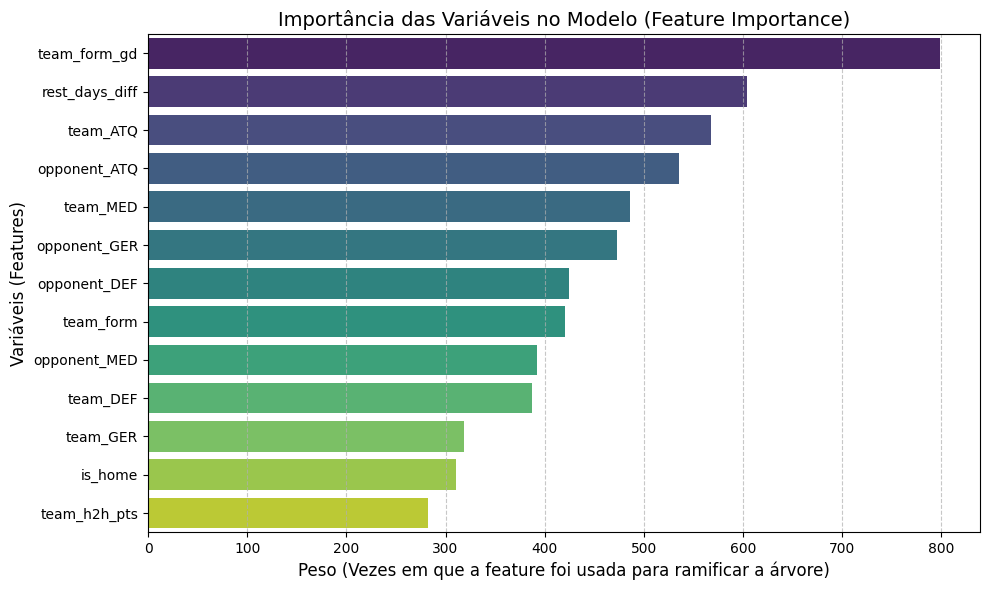

,Feature,Importância
4,team_form_gd,799
6,rest_days_diff,604
7,team_ATQ,568
10,opponent_ATQ,535
8,team_MED,486
2,opponent_GER,473
12,opponent_DEF,424
3,team_form,420
11,opponent_MED,392
9,team_DEF,387


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# SEÇÃO EXTRA: FEATURE IMPORTANCE DO LIGHTGBM
# ============================================================
print("Gerando gráfico de importância das variáveis...")

# 1. Criar um DataFrame cruzando os nomes das features com seus pesos no modelo
df_importancia = pd.DataFrame({
    'Feature': features,
    'Importância': modelo_lgbm.feature_importances_
})

# 2. Ordenar da mais importante para a menos importante
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)

# 3. Configurar e exibir o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Feature', data=df_importancia, palette='viridis')

plt.title('Importância das Variáveis no Modelo (Feature Importance)', fontsize=14)
plt.xlabel('Peso (Vezes em que a feature foi usada para ramificar a árvore)', fontsize=12)
plt.ylabel('Variáveis (Features)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Opcional: exibir em formato de tabela logo abaixo do gráfico
display(df_importancia)

In [24]:
import re
import numpy as np
import pandas as pd
import lightgbm as lgb
from scipy.stats import poisson
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SEÇÃO 1: CONFIGURAÇÃO GLOBAL E REPESCAGEM
# ============================================================
print("=" * 62)
print("SEÇÃO 1: CONFIGURAÇÃO GLOBAL E REPESCAGEM (COPA 2026)")
print("=" * 62)

MAX_GOLS = 8
N_SIMULACOES = 1000

playoff_map = {
    'FIFA Playoff 1': 'Congo DR',
    'FIFA Playoff 2': 'Iraq',
    'UEFA Playoff A': 'Bosnia and Herzegovina',
    'UEFA Playoff B': 'Sweden',
    'UEFA Playoff C': 'Turkey',
    'UEFA Playoff D': 'Czech Republic',
    'South Korea': 'Korea Republic',
    'United States': 'USA'
}

group_fixtures['home_team'] = group_fixtures['home_team'].replace(playoff_map)
group_fixtures['away_team'] = group_fixtures['away_team'].replace(playoff_map)

# ============================================================
# SEÇÃO 2: PREPARAÇÃO COM DADOS TÁTICOS E NOVAS FEATURES
# ============================================================
print("Modelando dados e injetando features de performance...")

# Adicionadas as features de Saldo de Gols, H2H e Descanso
colunas_necessarias = [
    'home_score', 'away_score', 'home_GER', 'away_GER',
    'home_ATQ', 'home_MED', 'home_DEF', 'away_ATQ', 'away_MED', 'away_DEF',
    'home_form_pts', 'away_form_pts', 'home_form_gd', 'away_form_gd',
    'home_h2h_pts', 'away_h2h_pts', 'rest_days_diff'
]

df_limpo = df.dropna(subset=colunas_necessarias).copy()
df_limpo['date'] = pd.to_datetime(df_limpo['date'])

cols_home = [
    'date', 'home_team', 'away_team', 'home_score', 'home_GER', 'away_GER',
    'home_form_pts', 'home_form_gd', 'home_h2h_pts', 'rest_days_diff',
    'home_ATQ', 'home_MED', 'home_DEF', 'away_ATQ', 'away_MED', 'away_DEF'
]

cols_unificadas = [
    'date', 'team', 'opponent', 'goals', 'team_GER', 'opponent_GER',
    'team_form', 'team_form_gd', 'team_h2h_pts', 'rest_days_diff',
    'team_ATQ', 'team_MED', 'team_DEF', 'opponent_ATQ', 'opponent_MED', 'opponent_DEF'
]

df_home = df_limpo[cols_home].copy()
df_home.columns = cols_unificadas
df_home['is_home'] = 1

cols_away = [
    'date', 'away_team', 'home_team', 'away_score', 'away_GER', 'home_GER',
    'away_form_pts', 'away_form_gd', 'away_h2h_pts', 'rest_days_diff',
    'away_ATQ', 'away_MED', 'away_DEF', 'home_ATQ', 'home_MED', 'home_DEF'
]
df_away = df_limpo[cols_away].copy()
df_away.columns = cols_unificadas
df_away['is_home'] = 0
df_away['rest_days_diff'] = -df_away['rest_days_diff'] # Inversão lógica para o visitante

poisson_data = pd.concat([df_home, df_away]).sort_values('date').reset_index(drop=True)

latest_stats = {}
for team in poisson_data['team'].unique():
    last_match = poisson_data[poisson_data['team'] == team].iloc[-1]
    latest_stats[team] = {
        'GER': last_match['team_GER'], 'form': last_match['team_form'],
        'form_gd': last_match['team_form_gd'], 'ATQ': last_match['team_ATQ'],
        'MED': last_match['team_MED'], 'DEF': last_match['team_DEF']
    }

default_stats = {
    'GER': poisson_data['team_GER'].mean(), 'form': 5.0, 'form_gd': 0.0,
    'ATQ': poisson_data['team_ATQ'].mean(), 'MED': poisson_data['team_MED'].mean(),
    'DEF': poisson_data['team_DEF'].mean()
}

# ============================================================
# SEÇÃO 3: O MOTOR LIGHTGBM
# ============================================================
print("Treinando Inteligência Artificial LightGBM...")

features = [
    'is_home', 'team_GER', 'opponent_GER', 'team_form', 'team_form_gd',
    'team_h2h_pts', 'rest_days_diff',
    'team_ATQ', 'team_MED', 'team_DEF',
    'opponent_ATQ', 'opponent_MED', 'opponent_DEF'
]

X = poisson_data[features].astype('float32')
y = poisson_data['goals'].astype('float32')

dias_atras = (poisson_data['date'].max() - poisson_data['date']).dt.days
pesos = np.exp(-dias_atras / 1095).astype('float32')

modelo_lgbm = lgb.LGBMRegressor(
    objective='poisson',
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    n_jobs=1,
    force_col_wise=True
)

modelo_lgbm.fit(X, y, sample_weight=pesos)
print("✅ LightGBM treinado com sucesso (Pesos Temporais Aplicados)!\n")

def get_lambda_lgbm(team_attack, team_defense, is_home):
    t = latest_stats.get(team_attack, default_stats)
    d = latest_stats.get(team_defense, default_stats)
    X_pred = pd.DataFrame([{
        'is_home': is_home,
        'team_GER': t['GER'], 'opponent_GER': d['GER'],
        'team_form': t['form'], 'team_form_gd': t['form_gd'],
        'team_h2h_pts': 1.0, 'rest_days_diff': 0.0,
        'team_ATQ': t['ATQ'], 'team_MED': t['MED'], 'team_DEF': t['DEF'],
        'opponent_ATQ': d['ATQ'], 'opponent_MED': d['MED'], 'opponent_DEF': d['DEF']
    }])
    return max(0.1, modelo_lgbm.predict(X_pred)[0])

def simular_partida(home_team, away_team, neutral=True):
    lam = get_lambda_lgbm(home_team, away_team, is_home=0 if neutral else 1)
    mu  = get_lambda_lgbm(away_team, home_team, is_home=0)
    h = int(min(np.random.poisson(lam), MAX_GOLS))
    a = int(min(np.random.poisson(mu),  MAX_GOLS))
    return h, a

# ============================================================
# SEÇÃO 4: MOTOR MONTE CARLO (MÓDULO DE GRUPOS 2026)
# ============================================================
print("=" * 62)
print(f"🎲 MONTE CARLO — {N_SIMULACOES} SIMULAÇÕES (FASE DE GRUPOS)")
print("=" * 62)

grupos = group_fixtures.groupby('group').apply(lambda g: list(set(g['home_team'].tolist() + g['away_team'].tolist()))).to_dict()
jogos_grupo = group_fixtures[['group', 'home_team', 'away_team']].to_dict('records')

np.random.seed(42)

acc_placar_grupo = defaultdict(Counter)
acc_posicao      = defaultdict(Counter)
acc_avanco       = Counter()

for n in range(N_SIMULACOES):
    if (n + 1) % 200 == 0:
        print(f"  ▶ {n + 1}/{N_SIMULACOES} simulações concluídas...")

    terceiros_deste_universo = []

    for grupo, times in grupos.items():
        tabela = {t: {'Pts': 0, 'GF': 0, 'GC': 0, 'SG': 0} for t in times}

        for jogo in [j for j in jogos_grupo if j['group'] == grupo]:
            ht, at = jogo['home_team'], jogo['away_team']
            h, a = simular_partida(ht, at, neutral=True)

            acc_placar_grupo[(ht, at)][(h, a)] += 1

            tabela[ht]['GF'] += h; tabela[ht]['GC'] += a; tabela[ht]['SG'] += h - a
            tabela[at]['GF'] += a; tabela[at]['GC'] += h; tabela[at]['SG'] += a - h

            if   h > a:  tabela[ht]['Pts'] += 3
            elif h == a: tabela[ht]['Pts'] += 1; tabela[at]['Pts'] += 1
            else:        tabela[at]['Pts'] += 3

        classif = sorted(tabela.items(), key=lambda x: (x[1]['Pts'], x[1]['SG'], x[1]['GF']), reverse=True)

        for pos, (team, _) in enumerate(classif, 1):
            acc_posicao[(grupo, team)][pos] += 1

        acc_avanco[classif[0][0]] += 1
        acc_avanco[classif[1][0]] += 1
        terceiros_deste_universo.append((classif[2][0], classif[2][1], grupo))

    melhores_3os = sorted(terceiros_deste_universo, key=lambda x: (x[1]['Pts'], x[1]['SG'], x[1]['GF']), reverse=True)[:8]
    for time_3o, _, _ in melhores_3os:
        acc_avanco[time_3o] += 1

print(f"\n✅ {N_SIMULACOES} simulações da Fase de Grupos concluídas!\n")

# ============================================================
# SEÇÃO 5: FASE DE GRUPOS — EXIBIÇÃO E EXTRAÇÃO DA MODA
# ============================================================
print("=" * 62)
print("📊 FASE DE GRUPOS — PROBABILIDADES DE CLASSIFICAÇÃO")
print("=" * 62)

def _pos_media(grupo, team):
    c   = acc_posicao.get((grupo, team), Counter({1: 1}))
    tot = sum(c.values())
    return sum(p * v for p, v in c.items()) / tot if tot > 0 else 4.0

modo_primeiros = {}
modo_segundos = {}
modo_terceiros_lista = []

# Primeira passagem: extrair quem realmente avança pela Moda para usar na exibição
for grupo in sorted(grupos.keys()):
    times_g = grupos[grupo]
    classif_mc = sorted(times_g, key=lambda t: _pos_media(grupo, t))
    modo_primeiros[grupo] = classif_mc[0]
    modo_segundos[grupo]  = classif_mc[1]
    modo_terceiros_lista.append((classif_mc[2], None, grupo))

modo_melhores_3os = sorted(modo_terceiros_lista, key=lambda x: acc_avanco.get(x[0], 0), reverse=True)[:8]
times_classificados = list(modo_primeiros.values()) + list(modo_segundos.values()) + [t[0] for t in modo_melhores_3os]

# Segunda passagem: Exibição
for grupo in sorted(grupos.keys()):
    print(f"\n{'─' * 62}")
    print(f"  GRUPO {grupo}")
    print(f"{'─' * 62}")

    times_g = grupos[grupo]
    classif_mc = sorted(times_g, key=lambda t: _pos_media(grupo, t))

    print(f"  {'Pos':<4} {'Seleção':<20}  {'1º%':>4}  {'2º%':>4}  {'3º%':>4}  {'4º%':>4} | {'Avança%':>6}")
    print(f"  {'─' * 60}")
    for rank, team in enumerate(classif_mc, 1):
        c   = acc_posicao.get((grupo, team), Counter())
        tot = sum(c.values()) or 1
        p1  = c.get(1, 0) / tot * 100
        p2  = c.get(2, 0) / tot * 100
        p3  = c.get(3, 0) / tot * 100
        p4  = c.get(4, 0) / tot * 100
        p_avanca = (acc_avanco[team] / N_SIMULACOES) * 100

        # O ícone reflete as 32 seleções que de fato vão para o mata-mata neste chaveamento
        icon = "✅" if team in times_classificados else "❌"
        print(f"  {icon} {rank:<2} {team:<20}  {p1:>3.0f}%  {p2:>3.0f}%  {p3:>3.0f}%  {p4:>3.0f}% | {p_avanca:>6.1f}%")

    print(f"\n  ┌─ PLACARES MAIS FREQUENTES ─────────────────────────┐")
    for jogo in [j for j in jogos_grupo if j['group'] == grupo]:
        ht, at = jogo['home_team'], jogo['away_team']
        cnt    = acc_placar_grupo.get((ht, at), Counter())
        if not cnt: continue
        total  = sum(cnt.values())
        top3   = cnt.most_common(3)
        top3_str = "  |  ".join(f"{h}-{a} ({v / total * 100:.0f}%)" for (h, a), v in top3)
        print(f"  │  {ht:20s} vs {at}")
        print(f"  │  Moda:  {top3_str}")
        print(f"  │")
    print(f"  └{'─' * 52}┘")

print("\n" + "=" * 62)
print("💾 ARQUIVAMENTO DA FASE DE GRUPOS CONCLUÍDO COM SUCESSO!")
print("=" * 62)
print(f"-> 3ºs Lugares Selecionados para Avançar: {[t[0] for t in modo_melhores_3os]}")

# ============================================================
# SEÇÃO 6: EXPORTAÇÃO KAGGLE (FASE DE GRUPOS)
# ============================================================
print("\n" + "=" * 62)
print("📁 GERANDO ARQUIVO FASE DE GRUPOS")
print("=" * 62)

previsoes_grupos = []
for index, row in group_fixtures.iterrows():
    match_id = row['match_id']
    ht = row['home_team']
    at = row['away_team']

    cnt = acc_placar_grupo.get((ht, at), Counter())
    cnt = acc_placar_grupo.get((ht, at), Counter())
if cnt:
    # ── Passo 1: Âncora de Resultado ──────────────────────────────
    home_wins = sum(v for (h, a), v in cnt.items() if h > a)
    draws     = sum(v for (h, a), v in cnt.items() if h == a)
    away_wins = sum(v for (h, a), v in cnt.items() if h < a)

    dominante = max(home_wins, draws, away_wins)

    if dominante == home_wins:
        filtro = Counter({s: v for s, v in cnt.items() if s[0] > s[1]})
    elif dominante == draws:
        filtro = Counter({s: v for s, v in cnt.items() if s[0] == s[1]})
    else:
        filtro = Counter({s: v for s, v in cnt.items() if s[0] < s[1]})

    # ── Passo 2: Moda dentro do universo filtrado ──────────────────
    (h_moda, a_moda), _ = filtro.most_common(1)[0]
else:
    h_moda, a_moda = 0, 0

    score_str = f"{h_moda}-{a_moda}"
    winner = 'home' if h_moda > a_moda else ('away' if a_moda > h_moda else 'draw')

    previsoes_grupos.append({
        'match_id': match_id,
        'Score': score_str,
        'Winning team': winner
    })

df_kaggle_grupos = pd.DataFrame(previsoes_grupos)

# ============================================================
# SEÇÃO 9: MATA-MATA DETERMINÍSTICO E EXPORTAÇÃO KAGGLE
# ============================================================
print("\n" + "=" * 62)
print("⚔️ SIMULAÇÃO DO MATA-MATA 2026 (Caminho da Moda)")
print("=" * 62)

def simular_partida_deterministica(home_team, away_team):
    lam = get_lambda_lgbm(home_team, away_team, is_home=0)
    mu  = get_lambda_lgbm(away_team, home_team, is_home=0)

    goals = np.arange(MAX_GOLS + 1)
    matrix = np.outer(poisson.pmf(goals, lam), poisson.pmf(goals, mu))
    idx = np.argmax(matrix)
    h, a = divmod(idx, MAX_GOLS + 1)
    return h, a

w_bracket = {}
l_bracket = {}
alocados  = set()
previsoes_ko = []

def alocar_3o(slot_desc):
    match = re.search(r'\((.*?)\)', str(slot_desc))
    if match:
        grupos_permitidos = match.group(1).split('/')
        for t, _, grp in modo_melhores_3os:
            if grp in grupos_permitidos and t not in alocados:
                alocados.add(t); return t
    for t, _, grp in modo_melhores_3os:
        if t not in alocados:
            alocados.add(t); return t
    return 'TBD'

def resolver(slot_desc):
    s = str(slot_desc).strip()
    if s.startswith('Winner Group'):    return modo_primeiros.get(s[-1], 'TBD')
    if s.startswith('Runner-up Group'): return modo_segundos.get(s[-1], 'TBD')
    if s.startswith('Best 3rd'):        return alocar_3o(s)
    if s.startswith('Winner Match'):    return w_bracket.get(int(s.split()[-1]), 'TBD')
    if s.startswith('Loser Match'):     return l_bracket.get(int(s.split()[-1]), 'TBD')
    return 'TBD'

fase_atual = ""
knockout_slots = knockout_slots.sort_values('match_id')

for _, row in knockout_slots.iterrows():
    m_id = row['match_id']
    fase = row['round']
    ht = resolver(row['slot_home'])
    at = resolver(row['slot_away'])

    if fase != fase_atual:
        print(f"\n{'═' * 62}")
        print(f"  {fase.upper()}")
        print(f"{'═' * 62}")
        fase_atual = fase

    if ht != 'TBD' and at != 'TBD':
        h, a = simular_partida_deterministica(ht, at)

        penalties = False
        if h > a:
            vencedor, perdedor = ht, at
            win_team_str = 'home'
        elif a > h:
            vencedor, perdedor = at, ht
            win_team_str = 'away'
        else:
            penalties = True
            ger_h = latest_stats.get(ht, default_stats)['GER']
            ger_a = latest_stats.get(at, default_stats)['GER']
            if ger_h >= ger_a:
                vencedor, perdedor = ht, at
                win_team_str = 'home'
            else:
                vencedor, perdedor = at, ht
                win_team_str = 'away'

        w_bracket[m_id] = vencedor
        l_bracket[m_id] = perdedor

        resultado_str = f"  [{m_id:>3}] {ht:20s} {h} x {a}  {at}"
        print(resultado_str)
        if penalties:
            print(f"        ↳ {vencedor} vence nos pênaltis")

        previsoes_ko.append({
            'match_id': m_id,
            'home_team': ht,
            'away_team': at,
            'Score': f"{h}-{a}",
            'Winning team': win_team_str,
            'Penalties': penalties
        })

print("\n" + "🌟" * 31)
print(f"🏆 O GRANDE CAMPEÃO: {w_bracket[max(w_bracket.keys())].upper()} 🏆")
print("🌟" * 31)

# ============================================================
# 4. CONSTRUÇÃO DO CSV FINAL ÚNICO
# ============================================================
print("\n" + "=" * 62)
print("📁 GERANDO ARQUIVO DE SUBMISSÃO FINAL (GRUPOS + MATA-MATA)")
print("=" * 62)

df_kaggle_ko = pd.DataFrame(previsoes_ko)
df_kaggle_grupos_completo = df_kaggle_grupos.copy()

df_kaggle_grupos_completo['home_team'] = group_fixtures['home_team']
df_kaggle_grupos_completo['away_team'] = group_fixtures['away_team']
df_kaggle_grupos_completo['Penalties'] = False

colunas_ordem = ['match_id', 'home_team', 'away_team', 'Score',  'Winning team', 'Penalties']
df_kaggle_grupos_completo = df_kaggle_grupos_completo[colunas_ordem]
df_kaggle_ko = df_kaggle_ko[colunas_ordem]

df_submissao_final = pd.concat([df_kaggle_grupos_completo, df_kaggle_ko], ignore_index=True)

nome_arquivo_final = "Kaggle_Submission_Complete.csv"
df_submissao_final.to_csv(nome_arquivo_final, index=False)

print(f"✅ Arquivo '{nome_arquivo_final}' criado com sucesso com as 104 partidas!")
display(df_submissao_final.tail(10))

SEÇÃO 1: CONFIGURAÇÃO GLOBAL E REPESCAGEM (COPA 2026)
Modelando dados e injetando features de performance...
Treinando Inteligência Artificial LightGBM...
✅ LightGBM treinado com sucesso (Pesos Temporais Aplicados)!

🎲 MONTE CARLO — 1000 SIMULAÇÕES (FASE DE GRUPOS)
  ▶ 200/1000 simulações concluídas...
  ▶ 400/1000 simulações concluídas...
  ▶ 600/1000 simulações concluídas...
  ▶ 800/1000 simulações concluídas...
  ▶ 1000/1000 simulações concluídas...

✅ 1000 simulações da Fase de Grupos concluídas!

📊 FASE DE GRUPOS — PROBABILIDADES DE CLASSIFICAÇÃO

──────────────────────────────────────────────────────────────
  GRUPO A
──────────────────────────────────────────────────────────────
  Pos  Seleção                1º%   2º%   3º%   4º% | Avança%
  ────────────────────────────────────────────────────────────
  ✅ 1  Mexico                 33%   29%   23%   15% |   79.6%
  ✅ 2  Korea Republic         31%   28%   24%   18% |   77.5%
  ✅ 3  Czech Republic         28%   27%   27%   18% |   

,match_id,home_team,away_team,Score,Winning team,Penalties
94,95,USA,Portugal,0-1,away,False
95,96,Switzerland,Argentina,0-1,away,False
96,97,Germany,Morocco,1-1,home,True
97,98,Spain,Belgium,1-1,home,True
98,99,France,England,1-1,home,True
99,100,Portugal,Argentina,1-1,home,True
100,101,Germany,Spain,1-1,away,True
101,102,France,Portugal,1-1,home,True
102,103,Germany,Portugal,1-1,away,True
103,104,Spain,France,1-1,home,True
